In [10]:
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm

BASE=Path("/data/project_backup/swc_fix")
OUT=BASE/"morphology_comparison"
OUT.mkdir(exist_ok=True)

DATASETS={
    "Raw":[(BASE/"sk_lod1_783_healed_260609",1e-3)],
    "Repaired":[
        (BASE/"step6_out/no_soma_annotation",1e-3),
        (BASE/"step6_out/soma_pruned",1e-3),
        (BASE/"step6_out/no_soma",1e-3)],
    "NeuroMorpho":[(BASE/"neuromorph_data_260816_3D",1.)]
}

DIST_UM=2.0
N_WORKERS=25
CHUNKSIZE=50


def point_along_upstream(node,parent,xyz,dist):
    """Point dist μm upstream from branch point."""
    origin=xyz[node]
    cur=node
    d=0.

    while parent[cur]>=0:
        nxt=parent[cur]
        vec=xyz[nxt]-xyz[cur]
        L=np.linalg.norm(vec)

        if not np.isfinite(L) or L<=0:
            cur=nxt
            continue

        if d+L>=dist:
            return xyz[cur]+vec*(dist-d)/L

        d+=L
        cur=nxt

    return xyz[cur] if d>0 else None


def point_along_downstream(root,child,children,xyz,dist):
    """Point dist μm downstream; continue through nearby branch by straightest path."""
    origin=xyz[root]
    prev,cur=root,child
    d=0.

    while True:
        vec=xyz[cur]-xyz[prev]
        L=np.linalg.norm(vec)

        if np.isfinite(L) and L>0:
            if d+L>=dist:
                return xyz[prev]+vec*(dist-d)/L
            d+=L

        ch=children[cur]
        if not ch:
            return xyz[cur] if d>0 else None

        if len(ch)==1:
            nxt=ch[0]
        else:
            # Continue along the daughter most aligned with current trajectory
            vin=xyz[cur]-xyz[prev]
            nin=np.linalg.norm(vin)

            if nin<=0:
                nxt=ch[0]
            else:
                vin/=nin
                score=[]
                for c in ch:
                    v=xyz[c]-xyz[cur]
                    nv=np.linalg.norm(v)
                    score.append(np.dot(vin,v/nv) if nv>0 else -np.inf)
                nxt=ch[int(np.argmax(score))]

        prev,cur=cur,nxt


def analyze(job):
    path,ds,scale,key=job

    try:
        a=np.loadtxt(path,comments="#",usecols=range(7),ndmin=2)
        ids=a[:,0].astype(np.int64)
        xyz=a[:,2:5]*scale
        parid=a[:,6].astype(np.int64)

        if len(np.unique(ids))!=len(ids):
            raise ValueError("duplicate IDs")

        # ID -> row index
        order=np.argsort(ids)
        sid=ids[order]
        pos=np.searchsorted(sid,parid)

        valid=(parid>=0)&(pos<len(ids))
        q=np.flatnonzero(valid)
        valid[q]&=sid[pos[q]]==parid[q]

        parent=np.full(len(ids),-1,dtype=int)
        parent[valid]=order[pos[valid]]

        children=[[] for _ in range(len(ids))]
        for c in np.flatnonzero(valid):
            children[parent[c]].append(int(c))

        branch=[i for i,ch in enumerate(children) if len(ch)>=2]
        degree=Counter(len(children[i]) for i in branch)

        angles=[]

        for node in branch:
            if parent[node]<0:
                continue

            up=point_along_upstream(node,parent,xyz,DIST_UM)
            if up is None:
                continue

            # Incoming direction extended through the branch point
            vp=xyz[node]-up
            np_=np.linalg.norm(vp)
            if not np.isfinite(np_) or np_<=0:
                continue
            vp/=np_

            for child in children[node]:
                down=point_along_downstream(
                    node,child,children,xyz,DIST_UM
                )
                if down is None:
                    continue

                vd=down-xyz[node]
                nd=np.linalg.norm(vd)
                if not np.isfinite(nd) or nd<=0:
                    continue
                vd/=nd

                theta=np.degrees(
                    np.arccos(np.clip(np.dot(vp,vd),-1,1))
                )
                angles.append(theta)

        return {
            "dataset":ds,
            "file":key,
            "n_branch_points":len(branch),
            "n_deflection_angles":len(angles),
            "mean_deflection_angle_deg":np.mean(angles) if angles else np.nan,
            "median_deflection_angle_deg":np.median(angles) if angles else np.nan,
            **{f"degree_{k}":degree[k] for k in range(2,6)},
            "degree_ge6":sum(v for k,v in degree.items() if k>=6)
        }

    except Exception as e:
        return {"dataset":ds,"file":key,"error":repr(e)}


def main():
    jobs=[]

    for ds,folders in DATASETS.items():
        n=0
        for folder,scale in folders:
            paths=list(folder.rglob("*.swc"))
            n+=len(paths)

            for p in paths:
                key=str(p.relative_to(folder)) if ds=="NeuroMorpho" else p.name
                jobs.append((str(p),ds,scale,key))

        print(f"{ds}: {n:,} SWCs")

    rows,errors=[],[]

    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        for r in tqdm(
            ex.map(analyze,jobs,chunksize=CHUNKSIZE),
            total=len(jobs),
            desc="Analyzing"
        ):
            (errors if "error" in r else rows).append(r)

    df=pd.DataFrame(rows)
    df.to_csv(OUT/"branch_deflection_features.csv",index=False)

    # Branch-degree distribution
    degree_cols=["degree_2","degree_3","degree_4","degree_5","degree_ge6"]
    labels=["2","3","4","5","≥6"]
    out=[]

    for ds,g in df.groupby("dataset"):
        counts=g[degree_cols].sum().values
        total=counts.sum()
        for label,n in zip(labels,counts):
            out.append([ds,label,int(n),100*n/total if total else np.nan])

    pd.DataFrame(
        out,
        columns=["dataset","daughter_branches","count","fraction_percent"]
    ).to_csv(OUT/"branch_degree_distribution.csv",index=False)

    # Summary
    summary=df.groupby("dataset").agg(
        n_neurons=("file","size"),
        n_branch_points=("n_branch_points","sum"),
        n_angles=("n_deflection_angles","sum"),
        median_neuron_angle=("mean_deflection_angle_deg","median"),
        mean_neuron_angle=("mean_deflection_angle_deg","mean")
    ).reset_index()

    summary.to_csv(OUT/"branch_deflection_summary.csv",index=False)

    if errors:
        pd.DataFrame(errors).to_csv(OUT/"branch_deflection_errors.csv",index=False)

    print("\n",summary.to_string(index=False))
    print(f"\nErrors: {len(errors):,}")


if __name__=="__main__":
    main()

Raw: 139,273 SWCs
Repaired: 138,904 SWCs
NeuroMorpho: 32,841 SWCs


Analyzing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311018/311018 [08:50<00:00, 586.10it/s]



     dataset  n_neurons  n_branch_points  n_angles  median_neuron_angle  mean_neuron_angle
NeuroMorpho      32841          2118156   4213441            65.128184          64.995611
        Raw     139273         36978651  76624714            65.741994          66.212786
   Repaired     138904         39411842  78788617            65.708355          66.219291

Errors: 0



Branch deflection angle statistics
Raw vs Repaired        : Wilcoxon, n=138,901, p=1.575e-13, Bonferroni p=4.726e-13, r_rb=-0.0230
Raw vs NeuroMorpho     : Mann-Whitney U, n=139,269/32,745, p=1.180e-237, Bonferroni p=3.539e-237, r_rb=0.1167
Repaired vs NeuroMorpho: Mann-Whitney U, n=138,901/32,745, p=1.699e-232, Bonferroni p=5.097e-232, r_rb=0.1155


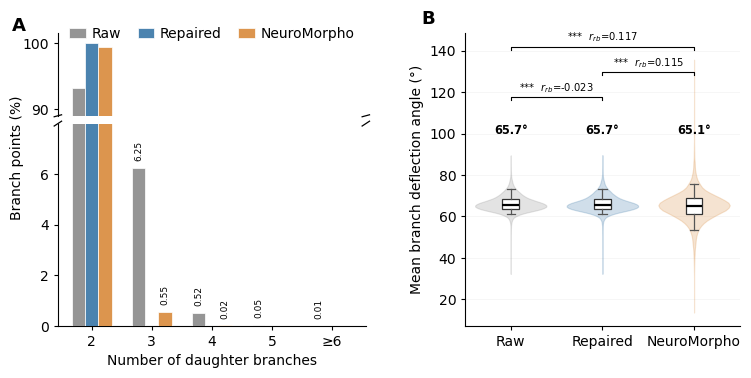

In [52]:
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.stats import wilcoxon,mannwhitneyu

root=Path("/data/project_backup/swc_fix/morphology_comparison")
deg=pd.read_csv(root/"branch_degree_distribution.csv")
feat=pd.read_csv(root/"branch_deflection_features.csv")
groups=["Raw","Repaired","NeuroMorpho"]; degrees=["2","3","4","5","≥6"]
col="mean_deflection_angle_deg"
colors={"Raw":"#8C8C8C","Repaired":"#3C78A8","NeuroMorpho":"#D98C3F"}

deg["daughter_branches"]=deg["daughter_branches"].astype(str)
f=feat[["dataset","file",col]].replace([np.inf,-np.inf],np.nan).dropna()

raw=f[f.dataset.eq("Raw")][["file",col]]
rep=f[f.dataset.eq("Repaired")][["file",col]]
pair=raw.merge(rep,on="file",suffixes=("_raw","_rep"))
x,y=pair[f"{col}_raw"].values,pair[f"{col}_rep"].values
ra=f.loc[f.dataset.eq("Raw"),col].values
rp=f.loc[f.dataset.eq("Repaired"),col].values
neu=f.loc[f.dataset.eq("NeuroMorpho"),col].values

p_rr=1 if np.allclose(x,y) else wilcoxon(x,y).pvalue
m_rn=mannwhitneyu(ra,neu,alternative="two-sided")
m_pn=mannwhitneyu(rp,neu,alternative="two-sided")
p_rn,p_pn=m_rn.pvalue,m_pn.pvalue
padj=np.minimum(np.array([p_rr,p_rn,p_pn])*3,1)

d=y-x; nz=d[np.isfinite(d)&(d!=0)]
if len(nz):
    r=pd.Series(np.abs(nz)).rank(method="average").values
    wp,wn=r[nz>0].sum(),r[nz<0].sum()
    rrb_rr=(wp-wn)/(wp+wn)
else: rrb_rr=0.

rrb_rn=2*m_rn.statistic/(len(ra)*len(neu))-1
rrb_pn=2*m_pn.statistic/(len(rp)*len(neu))-1

def stars(p):
    return "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"

print("\nBranch deflection angle statistics")
print(f"Raw vs Repaired        : Wilcoxon, n={len(pair):,}, p={p_rr:.3e}, Bonferroni p={padj[0]:.3e}, r_rb={rrb_rr:.4f}")
print(f"Raw vs NeuroMorpho     : Mann-Whitney U, n={len(ra):,}/{len(neu):,}, p={p_rn:.3e}, Bonferroni p={padj[1]:.3e}, r_rb={rrb_rn:.4f}")
print(f"Repaired vs NeuroMorpho: Mann-Whitney U, n={len(rp):,}/{len(neu):,}, p={p_pn:.3e}, Bonferroni p={padj[2]:.3e}, r_rb={rrb_pn:.4f}")

fig=plt.figure(figsize=(8.8,3.8))
gs=fig.add_gridspec(1,2,width_ratios=[1.12,1],wspace=.34)
gsa=gs[0].subgridspec(2,1,height_ratios=[1,2.45],hspace=.055)
a1,a2,b=fig.add_subplot(gsa[0]),fig.add_subplot(gsa[1]),fig.add_subplot(gs[1])

xp=np.arange(len(degrees)); w=.22; ys={}
for i,g in enumerate(groups):
    yy=(deg[deg.dataset.eq(g)].set_index("daughter_branches").reindex(degrees)["fraction_percent"].fillna(0).values)
    ys[g]=yy; xx=xp+(i-1)*w
    for ax in [a1,a2]:
        ax.bar(xx,yy,w,color=colors[g],edgecolor="white",lw=.55,alpha=.92,label=g if ax is a1 else None,zorder=3)

low=max(1.5,max(np.max(v[1:]) for v in ys.values())*1.28)
a1.set_ylim(89,101.5); a2.set_ylim(0,low)
a1.spines["bottom"].set_visible(False); a2.spines["top"].set_visible(False)
a1.tick_params(bottom=False,labelbottom=False)
a2.set(xticks=xp,xticklabels=degrees,xlabel="Number of daughter branches")
a2.set_ylabel("Branch points (%)"); a2.yaxis.set_label_coords(-.11,.83)

q=.012
for ax,y0,y1 in [(a1,-q,q),(a2,1-q,1+q)]:
    for x0,x1 in [(-q,q),(1-q,1+q)]:
        ax.plot((x0,x1),(y0,y1),transform=ax.transAxes,color="black",clip_on=False,lw=.9)

for i,g in enumerate(groups):
    yy=ys[g]; xx=xp+(i-1)*w
    for j in range(1,len(degrees)):
        if yy[j]>=.005:
            a2.text(xx[j],yy[j]+low*.035,f"{yy[j]:.2f}",ha="center",va="bottom",fontsize=6.5,rotation=90)

a1.legend(frameon=False,ncol=3,loc="upper center",bbox_to_anchor=(.5,1.23),columnspacing=1.2,handlelength=1.2,handletextpad=.4)

data=[f.loc[f.dataset.eq(g),col].values for g in groups]
pos=np.arange(1,4)
v=b.violinplot(data,positions=pos,widths=.78,showextrema=False)
for body,g in zip(v["bodies"],groups):
    body.set_facecolor(colors[g]); body.set_edgecolor(colors[g]); body.set_alpha(.24); body.set_linewidth(.8)

b.boxplot(data,positions=pos,widths=.18,patch_artist=True,showfliers=False,whis=(5,95),
          boxprops=dict(facecolor="white",edgecolor="#333333",lw=.9),
          whiskerprops=dict(color="#555555",lw=.9),
          capprops=dict(color="#555555",lw=.9),
          medianprops=dict(color="black",lw=1.6))

b.set(xticks=pos,xticklabels=groups,ylabel="Mean branch deflection angle (°)")
b.yaxis.grid(True,lw=.45,alpha=.18); b.set_axisbelow(True)

ymin,ymax=b.get_ylim(); yr=ymax-ymin
for x0,yy in zip(pos,data):
    b.text(x0,ymax-.28*yr,f"{np.median(yy):.1f}°",
           ha="center",va="top",fontsize=8.2,fontweight="semibold")

def sigbar(ax,x1,x2,y,h,label):
    ax.plot([x1,x1,x2,x2],[y,y+h,y+h,y],color="black",lw=.8,clip_on=False)
    ax.text((x1+x2)/2,y+h+.008*yr,label,ha="center",va="bottom",fontsize=7.2)

base=ymax-.19*yr
sigbar(b,1,2,base,.012*yr,f"{stars(padj[0])}  $r_{{rb}}$={rrb_rr:.3f}")
sigbar(b,2,3,base+.09*yr,.012*yr,f"{stars(padj[2])}  $r_{{rb}}$={rrb_pn:.3f}")
sigbar(b,1,3,base+.18*yr,.012*yr,f"{stars(padj[1])}  $r_{{rb}}$={rrb_rn:.3f}")

for ax in [a1,a2,b]:
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(.8)
    ax.spines["bottom"].set_linewidth(.8)
    ax.tick_params(direction="out",width=.8,length=3.2,pad=3)

a1.spines["top"].set_visible(False); b.spines["top"].set_visible(False)
a1.text(-.15,1.20,"A",transform=a1.transAxes,fontsize=13,fontweight="bold",va="top")
b.text(-.16,1.08,"B",transform=b.transAxes,fontsize=13,fontweight="bold",va="top")

plt.savefig(root/"branch_topology_deflection_main.pdf",bbox_inches="tight")
plt.savefig(root/"branch_topology_deflection_main.png",dpi=600,bbox_inches="tight")
plt.show()

## branches number around soma

In [48]:
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import numpy as np,pandas as pd
from tqdm import tqdm

BASE=Path("/data/project_backup/swc_fix"); OUT=BASE/"morphology_comparison"; OUT.mkdir(exist_ok=True)
DATASETS={
    "Raw":[(BASE/"sk_lod1_783_healed_260609",1e-3)],
    "Repaired":[
        (BASE/"step6_out/no_soma_annotation",1e-3),
        (BASE/"step6_out/soma_pruned",1e-3),
        (BASE/"step6_out/no_soma",1e-3)],
    "NeuroMorpho":[(BASE/"neuromorph_data_260816_type1",1.)]
}
RADIUS_UM=10.; N_WORKERS=25; CHUNKSIZE=300

def analyze(job):
    path,ds,scale,key=job
    try:
        a=np.loadtxt(path,comments="#",usecols=range(7),ndmin=2)
        ids=a[:,0].astype(np.int64); typ=a[:,1].astype(np.int16)
        xyz=a[:,2:5]*scale; par=a[:,6].astype(np.int64)

        type1=np.flatnonzero(typ==1)
        root_type1=np.flatnonzero((typ==1)&(par<0))

        if not len(type1) or not len(root_type1):
            return {"dataset":ds,"file":key,"n_type1":len(type1),"n_root_type1":len(root_type1),
                    "n_branch_points_10um":np.nan,"soma_branch_count_10um":np.nan}

        soma=int(root_type1[0])

        order=np.argsort(ids); sid=ids[order]; pos=np.searchsorted(sid,par)
        valid=(par>=0)&(pos<len(ids)); q=np.flatnonzero(valid)
        valid[q]&=sid[pos[q]]==par[q]

        parent=np.full(len(ids),-1,dtype=np.int32)
        parent[valid]=order[pos[valid]]
        cc=np.bincount(parent[valid],minlength=len(ids))

        bp=np.flatnonzero((cc>=2)&(typ!=1))

        if not len(bp):
            return {"dataset":ds,"file":key,"n_type1":len(type1),"n_root_type1":len(root_type1),
                    "n_branch_points_10um":0,"soma_branch_count_10um":0}

        children=[[] for _ in ids]
        edge=np.zeros(len(ids),dtype=np.float32)

        for c in np.flatnonzero(valid):
            p=parent[c]
            children[p].append(c)
            edge[c]=np.linalg.norm(xyz[c]-xyz[p])

        dist=np.full(len(ids),np.inf,dtype=np.float32)
        dist[soma]=0.; stack=[soma]

        while stack:
            u=stack.pop()
            for v in children[u]:
                nd=dist[u]+edge[v]
                if nd<=RADIUS_UM:
                    dist[v]=nd
                    stack.append(v)

        near=bp[dist[bp]<=RADIUS_UM]

        return {"dataset":ds,"file":key,"n_type1":len(type1),"n_root_type1":len(root_type1),
                "n_branch_points_10um":len(near),
                "soma_branch_count_10um":int(np.sum(cc[near]-1))}

    except Exception as e:
        return {"dataset":ds,"file":key,"error":repr(e)}

def main():
    jobs=[]
    for ds,folders in DATASETS.items():
        n=0
        for folder,scale in folders:
            paths=list(folder.rglob("*.swc")); n+=len(paths)
            jobs += [(str(p),ds,scale,str(p.relative_to(folder)) if ds=="NeuroMorpho" else p.name) for p in paths]
        print(f"{ds}: {n:,} SWCs")

    rows,errors=[],[]
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        for r in tqdm(ex.map(analyze,jobs,chunksize=CHUNKSIZE),total=len(jobs),desc="Analyzing"):
            (errors if "error" in r else rows).append(r)

    df=pd.DataFrame(rows)
    df.to_csv(OUT/"soma_branch_10um_features.csv",index=False)

    v=df.dropna(subset=["soma_branch_count_10um"])
    s=v.groupby("dataset")["soma_branch_count_10um"].agg(
        n="size",mean="mean",median="median",std="std").reset_index()

    q=v.groupby("dataset")["soma_branch_count_10um"].quantile([.25,.75]).unstack()
    q.columns=["q25","q75"]
    s=s.merge(q,on="dataset")
    s.to_csv(OUT/"soma_branch_10um_summary.csv",index=False)

    if errors:
        pd.DataFrame(errors).to_csv(OUT/"soma_branch_10um_errors.csv",index=False)

    print("\nSoma-proximal branch count (topological distance ≤10 μm)")
    print(s.to_string(index=False))

    print("\nFiles without type=1:")
    print(df[df.n_type1.eq(0)].dataset.value_counts())

    print("\nFiles without root type=1:")
    print(df[df.n_root_type1.eq(0)].dataset.value_counts())

    print("\nMultiple type-1 nodes:")
    print(df[df.n_type1.gt(1)].dataset.value_counts())

    print(f"\nErrors: {len(errors):,}")

if __name__=="__main__":
    main()

Raw: 139,273 SWCs
Repaired: 138,904 SWCs
NeuroMorpho: 9,781 SWCs


Analyzing: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 287958/287958 [04:26<00:00, 1080.30it/s]



Soma-proximal branch count (topological distance ≤10 μm)
    dataset      n     mean  median       std  q25  q75
NeuroMorpho   9781 0.074634     0.0  0.788304  0.0  0.0
        Raw 134689 4.246820     0.0 13.957716  0.0  2.0
   Repaired 117662 0.345685     0.0  1.379113  0.0  0.0

Files without type=1:
dataset
Repaired    21242
Raw          4584
Name: count, dtype: int64

Files without root type=1:
dataset
Repaired    21242
Raw          4584
Name: count, dtype: int64

Multiple type-1 nodes:
dataset
NeuroMorpho    9781
Name: count, dtype: int64

Errors: 0



Soma-proximal branching statistics
Raw vs Repaired        : Wilcoxon, n=117,662, Bonferroni p=0.000e+00, r_rb=-0.9939
Raw vs NeuroMorpho     : Mann-Whitney U, n=134,689/9,781, Bonferroni p=0.000e+00, r_rb=0.4550
Repaired vs NeuroMorpho: Mann-Whitney U, n=117,662/9,781, Bonferroni p=2.806e-289, r_rb=0.1406


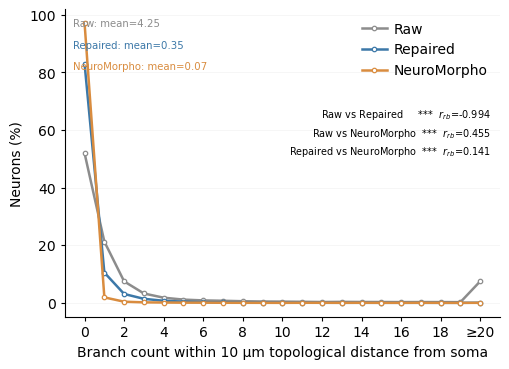

In [51]:
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.stats import wilcoxon,mannwhitneyu

root=Path("/data/project_backup/swc_fix/morphology_comparison")
df=pd.read_csv(root/"soma_branch_10um_features.csv")
groups=["Raw","Repaired","NeuroMorpho"]; col="soma_branch_count_10um"; MAX_BRANCH=20
colors={"Raw":"#8C8C8C","Repaired":"#3C78A8","NeuroMorpho":"#D98C3F"}

f=df[["dataset","file",col]].dropna()
raw=f[f.dataset.eq("Raw")][["file",col]]; rep=f[f.dataset.eq("Repaired")][["file",col]]
pair=raw.merge(rep,on="file",suffixes=("_raw","_rep"))
x,y=pair[f"{col}_raw"].values,pair[f"{col}_rep"].values
ra=f.loc[f.dataset.eq("Raw"),col].values
rp=f.loc[f.dataset.eq("Repaired"),col].values
neu=f.loc[f.dataset.eq("NeuroMorpho"),col].values

p_rr=1 if np.allclose(x,y) else wilcoxon(x,y).pvalue
m_rn=mannwhitneyu(ra,neu,alternative="two-sided")
m_pn=mannwhitneyu(rp,neu,alternative="two-sided")
padj=np.minimum(np.array([p_rr,m_rn.pvalue,m_pn.pvalue])*3,1)

d=y-x; nz=d[np.isfinite(d)&(d!=0)]
if len(nz):
    r=pd.Series(np.abs(nz)).rank(method="average").values
    rrb_rr=(r[nz>0].sum()-r[nz<0].sum())/r.sum()
else: rrb_rr=0.
rrb_rn=2*m_rn.statistic/(len(ra)*len(neu))-1
rrb_pn=2*m_pn.statistic/(len(rp)*len(neu))-1

def stars(p): return "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"

print("\nSoma-proximal branching statistics")
print(f"Raw vs Repaired        : Wilcoxon, n={len(pair):,}, Bonferroni p={padj[0]:.3e}, r_rb={rrb_rr:.4f}")
print(f"Raw vs NeuroMorpho     : Mann-Whitney U, n={len(ra):,}/{len(neu):,}, Bonferroni p={padj[1]:.3e}, r_rb={rrb_rn:.4f}")
print(f"Repaired vs NeuroMorpho: Mann-Whitney U, n={len(rp):,}/{len(neu):,}, Bonferroni p={padj[2]:.3e}, r_rb={rrb_pn:.4f}")

fig,ax=plt.subplots(figsize=(5.2,3.8)); stats={}

for g in groups:
    z=df.loc[df.dataset.eq(g),col].dropna().astype(int).values
    zc=np.minimum(z,MAX_BRANCH)
    pct=np.bincount(zc,minlength=MAX_BRANCH+1); pct=pct/pct.sum()*100
    stats[g]=(len(z),np.mean(z))
    ax.plot(np.arange(MAX_BRANCH+1),pct,color=colors[g],lw=1.8,
            marker="o",ms=3.2,mfc="white",mec=colors[g],mew=.9,
            label=g,zorder=3)

ticks=np.arange(0,MAX_BRANCH+1,2)
labels=[str(i) for i in ticks]; labels[-1]=f"≥{MAX_BRANCH}"

ax.set(
    xlabel="Branch count within 10 μm topological distance from soma",
    ylabel="Neurons (%)",
    xticks=ticks,
    xticklabels=labels
)

ax.legend(frameon=False,loc="upper right",handlelength=1.8,handletextpad=.5)
ax.spines[["top","right"]].set_visible(False)
ax.spines["left"].set_linewidth(.8)
ax.spines["bottom"].set_linewidth(.8)
ax.tick_params(direction="out",width=.8,length=3.2,pad=3)
ax.yaxis.grid(True,lw=.45,alpha=.18)
ax.set_axisbelow(True)

ymax=ax.get_ylim()[1]
for i,g in enumerate(groups):
    n,mean=stats[g]
    ax.text(
        .02,.97-i*.07,
        f"{g}: mean={mean:.2f}",
        transform=ax.transAxes,
        color=colors[g],
        fontsize=7.3,
        va="top"
    )

stat_text=(
    f"Raw vs Repaired     {stars(padj[0])}  $r_{{rb}}$={rrb_rr:.3f}\n"
    f"Raw vs NeuroMorpho  {stars(padj[1])}  $r_{{rb}}$={rrb_rn:.3f}\n"
    f"Repaired vs NeuroMorpho  {stars(padj[2])}  $r_{{rb}}$={rrb_pn:.3f}"
)

ax.text(
    .98,.68,stat_text,
    transform=ax.transAxes,
    ha="right",va="top",
    fontsize=7,
    linespacing=1.45
)

plt.tight_layout()
plt.savefig(root/"soma_branch_10um_distribution.pdf",bbox_inches="tight")
plt.savefig(root/"soma_branch_10um_distribution.png",dpi=600,bbox_inches="tight")
plt.show()